# Google Play Store Games - Exploratory Data Analysis (EDA)

## Importing Libraries and Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_games = pd.read_csv('google_play_games_dataset.csv')
df_games.head()

,Unnamed: 0,Game Name,Developer,Genre,Rating,Ratings Count,Reviews,Installs,Real Installs,Price,Free,Content Rating,Released,Updated,Version,Developer Website
0,0,The Eminence in Shadow RPG,"Crunchyroll Games, LLC",Role Playing,4.358610,37472.0,3017.0,"1,000,000+",1719752,0.0,True,Teen,"Nov 29, 2022",1.782342e+09,4.9.0,https://www.crunchyroll.com/games/eminenceinsh...
1,1,Quiz Blitz: Test Brain Game,Quiz & Trivia Games by Mno Go Apps,Trivia,4.814084,37460.0,310.0,"500,000+",505749,0.0,True,Everyone,"May 1, 2026",1.778245e+09,2.8.035,https://quizblitz.mnogoteams.com/
2,2,Disney Speedstorm,Gameloft SE,Racing,4.152659,42165.0,1589.0,"1,000,000+",4828185,0.0,True,Everyone,"Jul 11, 2024",1.780416e+09,1.19.0d,http://www.gameloft.com/
3,3,Alto's Odyssey,Noodlecake,Action,4.549542,285231.0,9249.0,"10,000,000+",29405049,0.0,True,Everyone,"Jul 25, 2018",1.760636e+09,1.0.42,http://www.noodlecake.com/games/altos-odyssey/
4,4,Battle Bag: War Zone,VOODOO,Strategy,3.968554,12317.0,544.0,"1,000,000+",2654797,0.0,True,Everyone 10+,"Apr 25, 2025",1.781114e+09,1.90.61,https://www.voodoo.io/


## Understanding Data

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.float_format', '{:.2f}'.format)

# Checking Rows and Columns of dataset
print('(Rows,Columns) : ', df_games.shape , end='\n\n')

# Checking Datatypes and Non Null Values of Columns
print(df_games.info(), end='\n\n')

# Checking Basic Statistics of Numeric Columns
print(df_games.describe(), end='\n\n')

(Rows,Columns) :  (595, 16)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 595 entries, 0 to 594
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         595 non-null    int64  
 1   Game Name          595 non-null    object 
 2   Developer          595 non-null    object 
 3   Genre              595 non-null    object 
 4   Rating             584 non-null    float64
 5   Ratings Count      584 non-null    float64
 6   Reviews            584 non-null    float64
 7   Installs           594 non-null    object 
 8   Real Installs      595 non-null    int64  
 9   Price              594 non-null    float64
 10  Free               595 non-null    bool   
 11  Content Rating     595 non-null    object 
 12  Released           590 non-null    object 
 13  Updated            586 non-null    float64
 14  Version            595 non-null    object 
 15  Developer Website  572 non-null    object 
dt

## Data Cleaning

In [4]:
# Checking NULL Values in our dataset
df_games.isnull().sum().sort_values(ascending=False)

Developer Website    23
Ratings Count        11
Rating               11
Reviews              11
Updated               9
Released              5
Price                 1
Installs              1
Unnamed: 0            0
Game Name             0
Developer             0
Genre                 0
Content Rating        0
Free                  0
Real Installs         0
Version               0
dtype: int64

In [5]:
# Categorical Columns 
df_games['Developer Website'] = df_games['Developer Website'].fillna('Not Available')
df_games['Released'] = df_games['Released'].fillna('Unknown')
df_games['Updated'] = df_games['Updated'].fillna('Unknown')

# Numerical Columns
df_games['Rating']=df_games['Rating'].fillna(0)
df_games['Ratings Count']=df_games['Rating'].fillna(0)
df_games['Reviews']=df_games['Rating'].fillna(0)

# Dropping Rows that has only 1 value missing and unnamed repeated index
df_games = df_games.dropna()
df_games.drop(columns=["Unnamed: 0"], inplace=True)

In [6]:
# After Filling Null Values Check Again if any remaining Null Value exist and checking shape of remaining cleaned dataset
print(df_games.isnull().sum(), end='\n\n')
print('(Rows,Columns) : ' , df_games.shape)

Game Name            0
Developer            0
Genre                0
Rating               0
Ratings Count        0
Reviews              0
Installs             0
Real Installs        0
Price                0
Free                 0
Content Rating       0
Released             0
Updated              0
Version              0
Developer Website    0
dtype: int64

(Rows,Columns) :  (594, 15)


# Exploratory Data Analysis (EDA)

## Top 10 Most Downloaded Games 

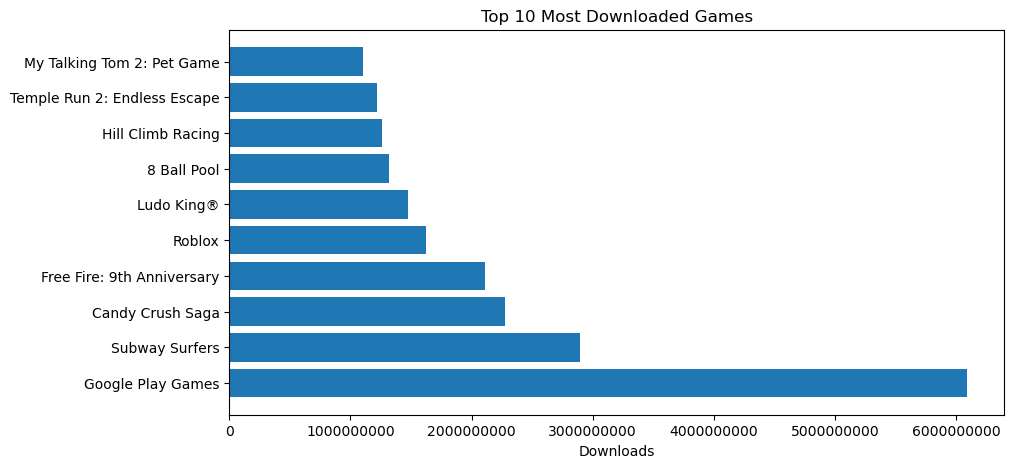

In [7]:
top_10_Games = df_games.sort_values('Real Installs', ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.barh( top_10_Games['Game Name'] , top_10_Games['Real Installs'])
plt.ticklabel_format(style='plain', axis='x')
plt.title("Top 10 Most Downloaded Games")
plt.xlabel("Downloads")
plt.show()

## Top Genre Of Games

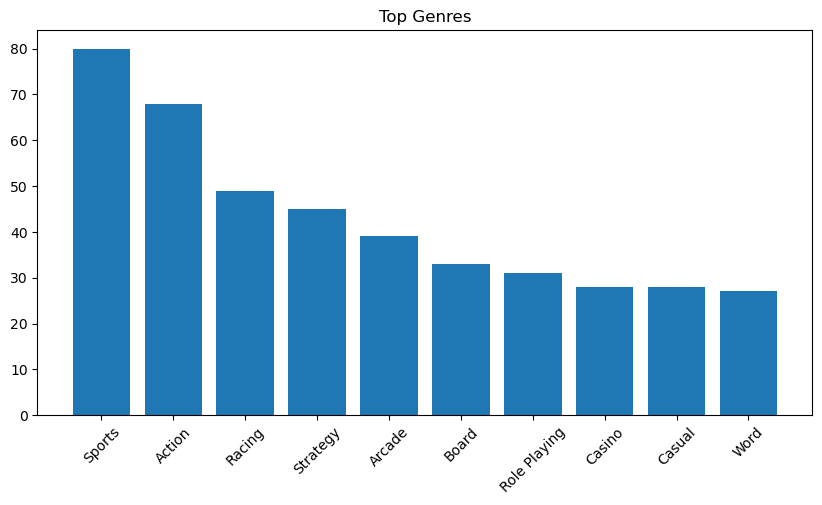

In [8]:
top_genre = df_games['Genre'].value_counts().head(10)
plt.figure(figsize=(10,5))
plt.bar( top_genre.index , top_genre.values)
plt.xticks(rotation=45)
plt.title("Top Genres")
plt.show()

## Rating Vs Downloads

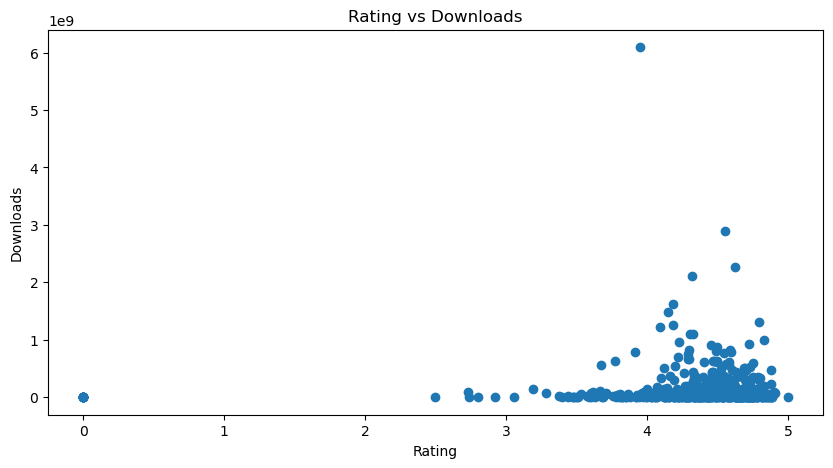

In [30]:
plt.figure(figsize=(10,5))
plt.scatter( df_games['Rating'], df_games['Real Installs'])
plt.title("Rating vs Downloads")
plt.xlabel("Rating")
plt.ylabel("Downloads")
plt.show()

## Free Vs Paid Games

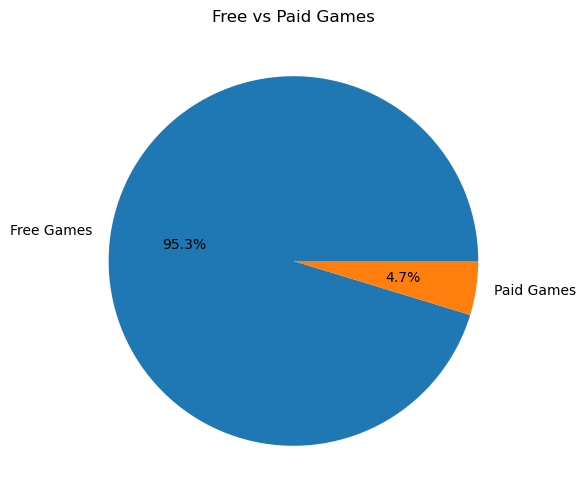

In [10]:
free_and_paid = df_games['Free'].value_counts()
custom_labels = ['Free Games', 'Paid Games']
plt.figure(figsize=(6,6))
plt.pie(
    free_and_paid.values,
    labels=custom_labels,
    autopct="%1.1f%%"
)
plt.title("Free vs Paid Games")
plt.show()

## Top 10 Developers

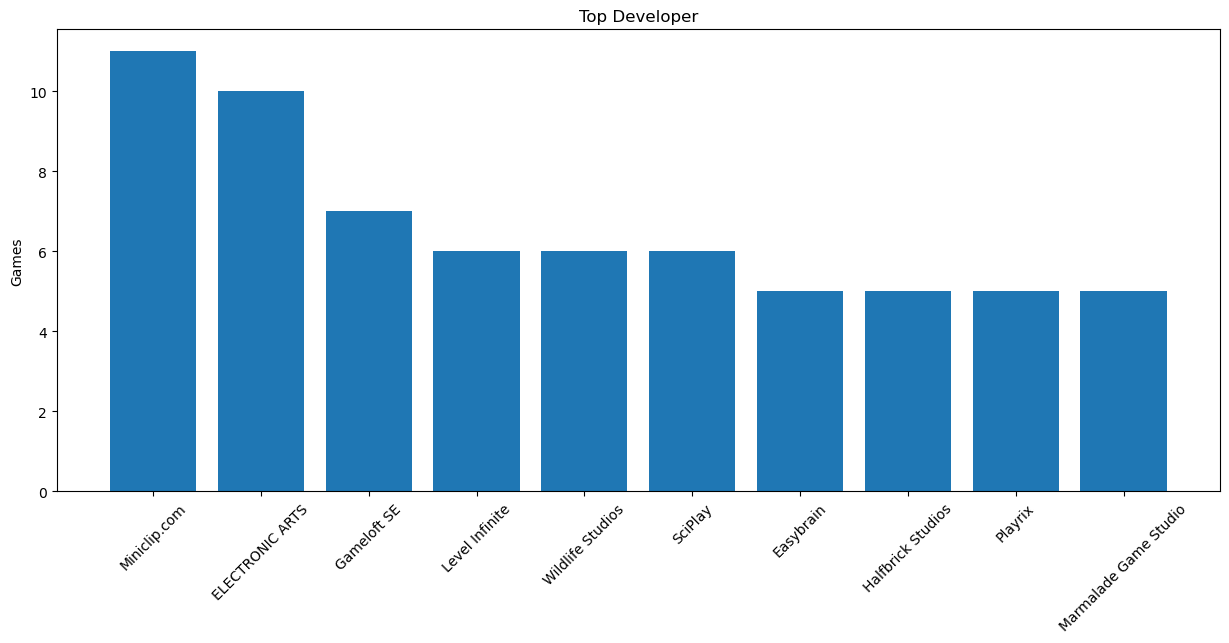

In [31]:
top_dev = df_games['Developer'].value_counts().head(10)
plt.figure(figsize=(15,6))
plt.bar( top_dev.index , top_dev.values)
plt.xticks(rotation=45)
plt.title('Top Developer')
plt.ylabel('Games')
plt.show()

## Target Audience

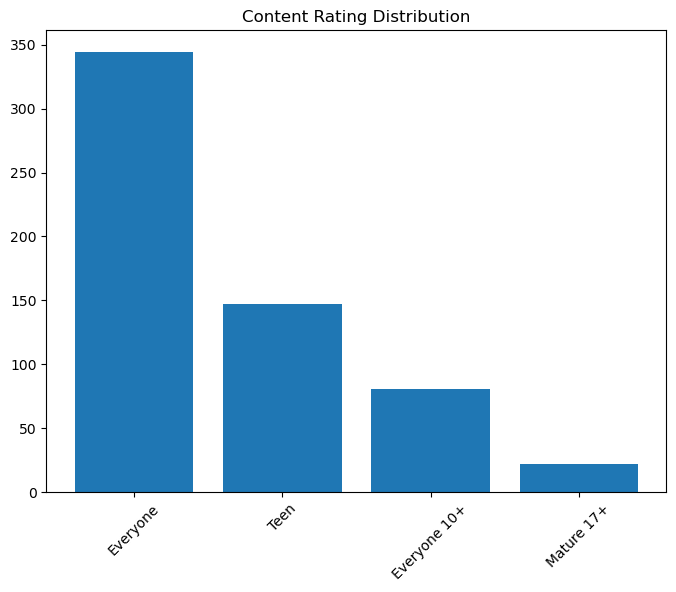

In [25]:
content = df_games['Content Rating'].value_counts()
plt.figure(figsize=(8,6))
plt.xticks(rotation=45)
plt.bar( content.index , content.values )
plt.title('Content Rating Distribution')
plt.show()

## Key Insights


- The dataset contains 595 Google Play Store games collected from various genres and developers.

- Sports and Action are the most common game genres in the dataset, indicating their strong presence on the Google Play Store.

- Google Play Games, Subway Surfers, and Candy Crush Saga are among the most downloaded games, demonstrating their widespread popularity among users.

- The majority of games have ratings between 4.0 and 5.0, suggesting generally positive user satisfaction.

- The scatter plot between Rating and Downloads indicates that highly rated games tend to attract more downloads, although rating alone does not completely determine a game's popularity.

- Approximately 95.3% of the games are free, while only 4.7% are paid, showing that free-to-play games dominate the mobile gaming market.

- Miniclip.com and Electronic Arts (EA) are among the most active developers in the dataset, publishing a significant number of games.

- Most games are targeted toward the "Everyone" audience, making them accessible to players of all age groups.

- Teen-rated games form the second largest category, while Mature 17+ games represent only a small portion of the dataset.

- Game popularity appears to be influenced by multiple factors, including ratings, accessibility, genre, and developer presence.

## Conclusion

This exploratory data analysis of Google Play Store Games revealed several interesting trends regarding mobile gaming applications. The analysis showed that free games dominate the Play Store, accounting for more than 95% of the dataset. Sports and Action emerged as the most common genres, while games such as Google Play Games, Subway Surfers, and Candy Crush Saga achieved the highest download counts.

Furthermore, most games received ratings above 4.0, indicating overall positive user feedback. The relationship between ratings and downloads suggests that highly rated games generally attract more users, although other factors also contribute to popularity. Content rating analysis revealed that most games are designed for a broad audience, particularly the "Everyone" category.

Overall, the findings demonstrate that accessibility, user ratings, genre popularity, and developer reputation play an important role in determining the success of games on the Google Play Store.